# Day 3: Hospital Readmission Risk Scorer

**Industry:** Healthcare  
**Format:** Jupyter Notebook (.ipynb)  
**Skills:** pandas · seaborn · matplotlib · SQL · sqlite3 · scoring models

**Data:** CMS Hospital Readmissions Reduction Program — official US government hospital performance data (1,500 records)

---

## Who uses this
A **hospital case manager or quality director** identifying which conditions and facilities have the worst readmission performance — so they can prioritise discharge follow-up calls, patient education, and care coordination resources.

## Problem
Under the CMS Hospital Readmissions Reduction Program (HRRP), US hospitals are financially penalised up to 3% of all Medicare payments if their readmission rates exceed expectations. A hospital with an Excess Readmission Ratio above 1.0 is performing worse than expected and is at risk of penalty. Without a systematic scoring tool, quality teams manually scan spreadsheets to find problem areas.

## What we build
1. Load and inspect CMS readmission data
2. Clean and prepare the data
3. Load into SQLite and run SQL analysis queries
4. Build a composite risk score per hospital
5. Tier hospitals into High / Medium / Low risk
6. Visualise with seaborn
7. Export intervention priority list

## Key metric: Excess Readmission Ratio (ERR)
- **ERR > 1.0** = hospital has MORE readmissions than expected for its patient mix → penalty risk
- **ERR = 1.0** = performing exactly as expected
- **ERR < 1.0** = performing better than expected → no penalty

CMS penalises hospitals with ERR > 1.0 across heart failure, pneumonia, COPD, hip/knee replacement, heart attack, and CABG surgery.

## Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import os
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully')

Libraries loaded successfully


## Step 2 — Load and Inspect the Data

In [2]:
df = pd.read_csv('hospital_readmissions.csv')

print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(f'\nUnique hospitals: {df["Facility ID"].nunique()}')
print(f'Unique conditions: {df["Measure Name"].nunique()}')
print(f'States covered: {df["State"].nunique()}')
print(f'\nConditions measured:')
for c in df['Measure Name'].unique():
    print(f'  - {c}')
df.head(5)

Shape: (1500, 12)
Columns: ['Facility Name', 'Facility ID', 'State', 'Measure Name', 'Number of Discharges', 'Footnote', 'Excess Readmission Ratio', 'Predicted Readmission Rate', 'Expected Readmission Rate', 'Number of Readmissions', 'Start Date', 'End Date']

Unique hospitals: 250
Unique conditions: 6
States covered: 5

Conditions measured:
  - READM-30-HIP-KNEE-HRRP
  - READM-30-CABG-HRRP
  - READM-30-AMI-HRRP
  - READM-30-COPD-HRRP
  - READM-30-PN-HRRP
  - READM-30-HF-HRRP


,Facility Name,Facility ID,State,Measure Name,Number of Discharges,Footnote,Excess Readmission Ratio,Predicted Readmission Rate,Expected Readmission Rate,Number of Readmissions,Start Date,End Date
0,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-HIP-KNEE-HRRP,NaN,NaN,0.9875,4.5734,4.6311,Too Few to Report,07/01/2021,06/30/2024
1,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-CABG-HRRP,137.0,NaN,0.9531,10.3960,10.9078,13,07/01/2021,06/30/2024
2,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-AMI-HRRP,273.0,NaN,0.9370,13.2998,14.1948,33,07/01/2021,06/30/2024
3,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-COPD-HRRP,122.0,NaN,0.9823,16.6384,16.9389,19,07/01/2021,06/30/2024
4,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-PN-HRRP,507.0,NaN,0.9871,15.7529,15.9591,79,07/01/2021,06/30/2024


## Step 3 — Inspect Data Quality

In [3]:
print('=== Null counts ===')
print(df.isnull().sum())

print('\n=== Data types ===')
print(df.dtypes)

print('\n=== Excess Readmission Ratio sample values ===')
print(df['Excess Readmission Ratio'].value_counts().head(10))

print('\n=== Number of Discharges sample ===')
print(df['Number of Discharges'].value_counts().head(10))

=== Null counts ===
Facility Name                   0
Facility ID                     0
State                           0
Measure Name                    0
Number of Discharges          875
Footnote                      885
Excess Readmission Ratio      579
Predicted Readmission Rate    579
Expected Readmission Rate     579
Number of Readmissions        579
Start Date                      0
End Date                        0
dtype: int64

=== Data types ===
Facility Name                     str
Facility ID                     int64
State                             str
Measure Name                      str
Number of Discharges          float64
Footnote                      float64
Excess Readmission Ratio      float64
Predicted Readmission Rate    float64
Expected Readmission Rate     float64
Number of Readmissions            str
Start Date                        str
End Date                          str
dtype: object

=== Excess Readmission Ratio sample values ===
Excess Readmission Ra

## Step 4 — Clean the Data

Key issues to handle:
- `Excess Readmission Ratio` and numeric columns may contain 'Not Available' strings — convert to numeric
- `Number of Discharges` may have 'Too Few to Report' entries — remove these
- Shorten condition names for cleaner charts
- Drop the Footnote column — not needed for analysis

In [4]:
# Convert numeric columns — coerce turns non-numeric values into NaN
numeric_cols = ['Excess Readmission Ratio', 'Predicted Readmission Rate',
                'Expected Readmission Rate', 'Number of Readmissions',
                'Number of Discharges']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows where Excess Readmission Ratio is missing — it is our key metric
df = df.dropna(subset=['Excess Readmission Ratio'])

# Drop Footnote column — not useful
df = df.drop(columns=['Footnote'], errors='ignore')

# Shorten condition names for cleaner charts
condition_map = {
    'READM-30-HF-HRRP':   'Heart Failure',
    'READM-30-AMI-HRRP':  'Heart Attack',
    'READM-30-PN-HRRP':   'Pneumonia',
    'READM-30-COPD-HRRP': 'COPD',
    'READM-30-HIP-KNEE-HRRP': 'Hip/Knee',
    'READM-30-CABG-HRRP': 'CABG Surgery'
}

# Also handle full name versions
condition_map_full = {
    'HEART FAILURE': 'Heart Failure',
    'ACUTE MYOCARDIAL INFARCTION': 'Heart Attack',
    'PNEUMONIA': 'Pneumonia',
    'CHRONIC OBSTRUCTIVE PULMONARY DISEASE': 'COPD',
    'HIP/KNEE ARTHROPLASTY': 'Hip/Knee',
    'CORONARY ARTERY BYPASS GRAFT': 'CABG Surgery'
}

df['Condition'] = df['Measure Name'].map(condition_map)
if df['Condition'].isnull().all():
    df['Condition'] = df['Measure Name'].str.upper().map(condition_map_full)
if df['Condition'].isnull().sum() > 0:
    df['Condition'] = df['Measure Name']  # fallback: use as-is

# Parse dates
df['Start Date'] = pd.to_datetime(df['Start Date'], errors='coerce')
df['End Date']   = pd.to_datetime(df['End Date'], errors='coerce')

print(f'Clean rows: {len(df):,}')
print(f'Hospitals: {df["Facility ID"].nunique()}')
print(f'Conditions: {df["Condition"].unique()}')
print(f'\nERR stats:')
print(df['Excess Readmission Ratio'].describe().round(3))
df.head(3)

Clean rows: 921
Hospitals: 227
Conditions: <StringArray>
[     'Hip/Knee',  'CABG Surgery',  'Heart Attack',          'COPD',
     'Pneumonia', 'Heart Failure']
Length: 6, dtype: str

ERR stats:
count    921.000
mean       1.007
std        0.080
min        0.719
25%        0.966
50%        1.003
75%        1.042
max        1.426
Name: Excess Readmission Ratio, dtype: float64


,Facility Name,Facility ID,State,Measure Name,Number of Discharges,Excess Readmission Ratio,Predicted Readmission Rate,Expected Readmission Rate,Number of Readmissions,Start Date,End Date,Condition
0,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-HIP-KNEE-HRRP,NaN,0.9875,4.5734,4.6311,NaN,2021-07-01,2024-06-30,Hip/Knee
1,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-CABG-HRRP,137.0,0.9531,10.3960,10.9078,13.0,2021-07-01,2024-06-30,CABG Surgery
2,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-AMI-HRRP,273.0,0.9370,13.2998,14.1948,33.0,2021-07-01,2024-06-30,Heart Attack


## Step 5 — Load into SQLite and Run SQL Analysis

We load the clean data into SQLite and run SQL queries to answer key questions. This is the ETL pattern: clean in pandas, analyse in SQL.

SQL is used here because in a real hospital system this data would live in a database — and the queries we write here translate directly to production BI tools.

In [5]:
# Create SQLite database and load data
conn = sqlite3.connect('hospital_readmissions.db')
df.to_sql('readmissions', conn, if_exists='replace', index=False)
print('Data loaded into SQLite')

# SQL Query 1 — Average ERR by condition (which condition has worst readmissions?)
q1 = pd.read_sql_query('''
    SELECT
        Condition,
        ROUND(AVG("Excess Readmission Ratio"), 3) AS avg_err,
        ROUND(AVG("Predicted Readmission Rate"), 2) AS avg_predicted_rate,
        ROUND(AVG("Expected Readmission Rate"), 2) AS avg_expected_rate,
        COUNT(*) AS hospital_count,
        SUM(CASE WHEN "Excess Readmission Ratio" > 1.0 THEN 1 ELSE 0 END) AS hospitals_at_risk
    FROM readmissions
    GROUP BY Condition
    ORDER BY avg_err DESC
''', conn)

print('\n=== SQL Query 1: Average ERR by condition ===')
print(q1.to_string())

Data loaded into SQLite

=== SQL Query 1: Average ERR by condition ===
       Condition  avg_err  avg_predicted_rate  avg_expected_rate  hospital_count  hospitals_at_risk
0   CABG Surgery    1.018               10.89              10.70              79                 45
1  Heart Failure    1.013               19.30              19.03             202                115
2   Heart Attack    1.011               13.21              13.06             134                 79
3      Pneumonia    1.007               15.19              15.07             218                113
4           COPD    0.998               17.45              17.47             176                 80
5       Hip/Knee    0.993                5.12               5.14             112                 50


In [6]:
# SQL Query 2 — Top 15 worst performing hospitals (highest avg ERR across all conditions)
q2 = pd.read_sql_query('''
    SELECT
        "Facility Name",
        State,
        ROUND(AVG("Excess Readmission Ratio"), 3) AS avg_err,
        COUNT(*) AS conditions_measured,
        SUM(CASE WHEN "Excess Readmission Ratio" > 1.0 THEN 1 ELSE 0 END) AS conditions_at_risk
    FROM readmissions
    GROUP BY "Facility ID"
    HAVING conditions_measured >= 2
    ORDER BY avg_err DESC
    LIMIT 15
''', conn)

print('=== SQL Query 2: Top 15 worst hospitals by avg ERR ===')
print(q2.to_string())

=== SQL Query 2: Top 15 worst hospitals by avg ERR ===
                                Facility Name State  avg_err  conditions_measured  conditions_at_risk
0                           OROVILLE HOSPITAL    CA    1.248                    5                   5
1              UNIVERSITY OF ALABAMA HOSPITAL    AL    1.152                    6                   4
2                            ST ROSE HOSPITAL    CA    1.116                    5                   5
3                               BAXTER HEALTH    AR    1.100                    6                   6
4                       RUSSELLVILLE HOSPITAL    AL    1.100                    3                   2
5              BANNER OCOTILLO MEDICAL CENTER    AZ    1.091                    2                   2
6                            FLOWERS HOSPITAL    AL    1.090                    6                   4
7                    ALASKA REGIONAL HOSPITAL    AK    1.086                    6                   5
8   NORTHEAST ALABAMA REGIO

In [7]:
# SQL Query 3 — State level analysis (which states have worst readmission performance?)
q3 = pd.read_sql_query('''
    SELECT
        State,
        ROUND(AVG("Excess Readmission Ratio"), 3) AS avg_err,
        COUNT(DISTINCT "Facility ID") AS hospitals,
        SUM(CASE WHEN "Excess Readmission Ratio" > 1.0 THEN 1 ELSE 0 END) AS records_at_risk,
        ROUND(100.0 * SUM(CASE WHEN "Excess Readmission Ratio" > 1.0 THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_at_risk
    FROM readmissions
    GROUP BY State
    HAVING hospitals >= 3
    ORDER BY avg_err DESC
    LIMIT 15
''', conn)

print('=== SQL Query 3: Top 15 worst states by avg ERR ===')
print(q3.to_string())

=== SQL Query 3: Top 15 worst states by avg ERR ===
  State  avg_err  hospitals  records_at_risk  pct_at_risk
0    AL    1.014         67              130         52.6
1    CA    1.011         55              140         56.0
2    AZ    1.001         57              115         49.6
3    AR    1.000         40               82         52.6
4    AK    0.987          8               15         41.7


## Step 6 — Build Hospital Risk Score

We build a composite risk score per hospital combining:
- **ERR score** — how far above 1.0 is their excess readmission ratio?
- **Breadth score** — how many conditions are they underperforming on?
- **Volume score** — high discharge volume means more patients at risk

Each component is normalised 0-10 and combined into a final risk score 0-10.

In [8]:
# Aggregate to hospital level
hospital = df.groupby(['Facility ID', 'Facility Name', 'State']).agg(
    avg_err=('Excess Readmission Ratio', 'mean'),
    max_err=('Excess Readmission Ratio', 'max'),
    conditions_at_risk=('Excess Readmission Ratio', lambda x: (x > 1.0).sum()),
    conditions_measured=('Excess Readmission Ratio', 'count'),
    total_discharges=('Number of Discharges', 'sum'),
    total_readmissions=('Number of Readmissions', 'sum')
).reset_index()

# Only score hospitals with at least 2 conditions measured
hospital = hospital[hospital['conditions_measured'] >= 2].copy()

# Normalise each component to 0-10
def normalise(series):
    min_val = series.min()
    max_val = series.max()
    if max_val == min_val:
        return pd.Series([5.0] * len(series), index=series.index)
    return ((series - min_val) / (max_val - min_val) * 10).round(2)

hospital['err_score']    = normalise(hospital['avg_err'])
hospital['breadth_score'] = normalise(hospital['conditions_at_risk'])
hospital['volume_score']  = normalise(hospital['total_discharges'].fillna(0))

# Composite score — ERR weighted highest (50%), breadth (30%), volume (20%)
hospital['risk_score'] = (
    hospital['err_score']    * 0.50 +
    hospital['breadth_score'] * 0.30 +
    hospital['volume_score']  * 0.20
).round(2)

# Tier hospitals
hospital['risk_tier'] = pd.cut(
    hospital['risk_score'],
    bins=[0, 3.33, 6.66, 10],
    labels=['Low Risk', 'Medium Risk', 'High Risk'],
    include_lowest=True
)

hospital = hospital.sort_values('risk_score', ascending=False).reset_index(drop=True)

print(f'Hospitals scored: {len(hospital):,}')
print(f'\nRisk tier breakdown:')
print(hospital['risk_tier'].value_counts().to_string())
print(f'\nTop 10 highest risk hospitals:')
print(hospital[['Facility Name', 'State', 'avg_err', 'conditions_at_risk', 'risk_score', 'risk_tier']].head(10).to_string())

Hospitals scored: 202

Risk tier breakdown:
risk_tier
Low Risk       125
Medium Risk     76
High Risk        1

Top 10 highest risk hospitals:
                                Facility Name State   avg_err  conditions_at_risk  risk_score    risk_tier
0                           OROVILLE HOSPITAL    CA  1.248360                   5        8.13    High Risk
1                               BAXTER HEALTH    AR  1.099833                   6        6.62  Medium Risk
2              UNIVERSITY OF ALABAMA HOSPITAL    AL  1.151550                   4        6.48  Medium Risk
3  HONORHEALTH SCOTTSDALE SHEA MEDICAL CENTER    AZ  1.064133                   6        6.28  Medium Risk
4                            ST ROSE HOSPITAL    CA  1.115520                   5        5.75  Medium Risk
5                RIVERSIDE COMMUNITY HOSPITAL    CA  1.058750                   6        5.70  Medium Risk
6                    ALASKA REGIONAL HOSPITAL    AK  1.086433                   5        5.69  Medium Risk
7

## Step 7 — Visualise

Four panels:
- **Top-left:** ERR distribution by condition (seaborn boxplot)
- **Top-right:** Risk tier breakdown (pie chart)
- **Bottom-left:** Top 15 worst hospitals by risk score (horizontal bar)
- **Bottom-right:** Top 15 worst states by avg ERR (horizontal bar)

Chart saved as readmission_risk_analysis.png


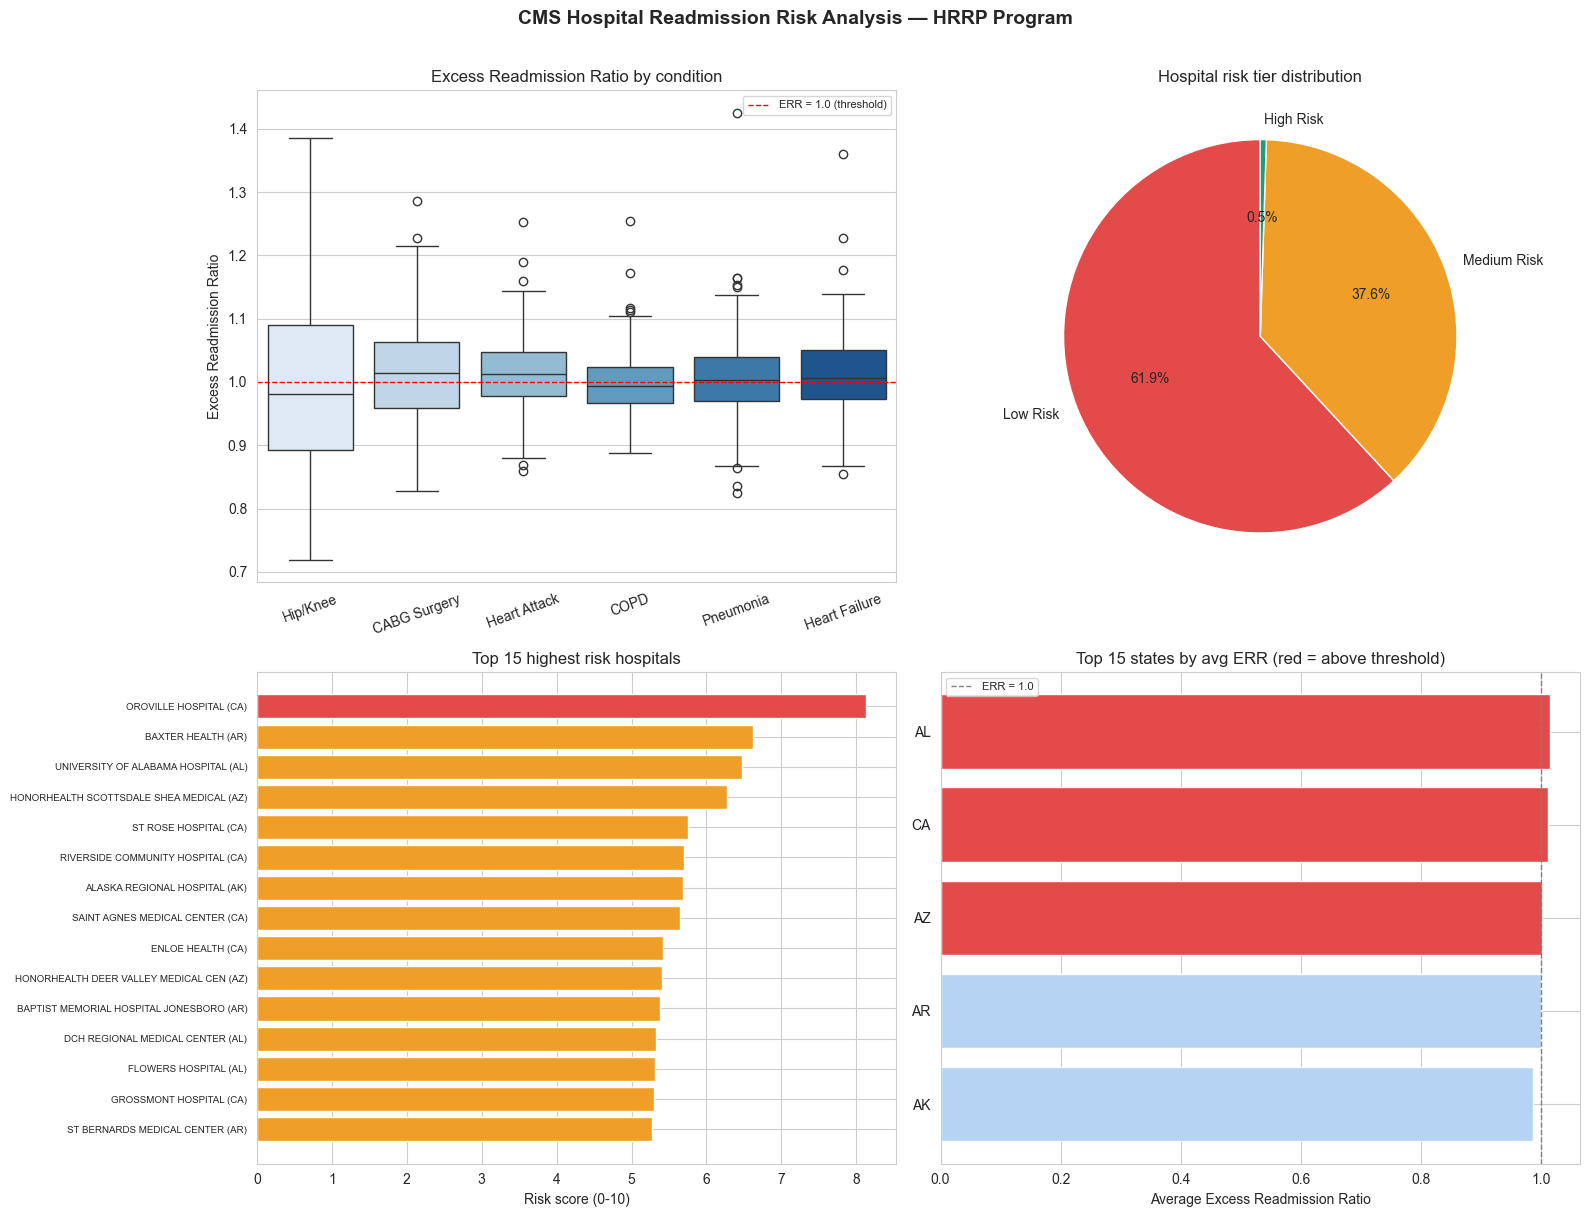

In [9]:
sns.set_style('whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('CMS Hospital Readmission Risk Analysis — HRRP Program',
             fontsize=14, fontweight='bold', y=1.01)

# Panel 1 — ERR distribution by condition (boxplot)
df_clean = df.dropna(subset=['Excess Readmission Ratio', 'Condition'])
sns.boxplot(
    data=df_clean,
    x='Condition',
    y='Excess Readmission Ratio',
    ax=axes[0, 0],
    palette='Blues'
)
axes[0, 0].axhline(1.0, color='red', linestyle='--', linewidth=1, label='ERR = 1.0 (threshold)')
axes[0, 0].set_title('Excess Readmission Ratio by condition')
axes[0, 0].set_xlabel('')
axes[0, 0].tick_params(axis='x', rotation=20)
axes[0, 0].legend(fontsize=8)

# Panel 2 — Risk tier pie chart
tier_counts = hospital['risk_tier'].value_counts()
colors = ['#E24B4A', '#EF9F27', '#1D9E75']
axes[0, 1].pie(
    tier_counts.values,
    labels=tier_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90
)
axes[0, 1].set_title('Hospital risk tier distribution')

# Panel 3 — Top 15 highest risk hospitals
top15 = hospital.head(15)
bar_colors = ['#E24B4A' if t == 'High Risk' else '#EF9F27'
              for t in top15['risk_tier']]
axes[1, 0].barh(
    top15['Facility Name'].str[:35] + ' (' + top15['State'] + ')',
    top15['risk_score'],
    color=bar_colors
)
axes[1, 0].set_xlabel('Risk score (0-10)')
axes[1, 0].set_title('Top 15 highest risk hospitals')
axes[1, 0].invert_yaxis()
axes[1, 0].tick_params(axis='y', labelsize=7)

# Panel 4 — Top 15 worst states
top_states = q3.head(15)
state_colors = ['#E24B4A' if v > 1.0 else '#B5D4F4' for v in top_states['avg_err']]
axes[1, 1].barh(top_states['State'], top_states['avg_err'], color=state_colors)
axes[1, 1].axvline(1.0, color='gray', linestyle='--', linewidth=1, label='ERR = 1.0')
axes[1, 1].set_xlabel('Average Excess Readmission Ratio')
axes[1, 1].set_title('Top 15 states by avg ERR (red = above threshold)')
axes[1, 1].invert_yaxis()
axes[1, 1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('readmission_risk_analysis.png', dpi=150, bbox_inches='tight')
print('Chart saved as readmission_risk_analysis.png')
plt.show()

## Step 8 — Export Results

In [10]:
os.makedirs('output', exist_ok=True)

# Full hospital risk scorecard
hospital.to_csv('output/hospital_risk_scorecard.csv', index=False)

# High risk hospitals only — the intervention list
high_risk = hospital[hospital['risk_tier'] == 'High Risk']
high_risk.to_csv('output/high_risk_hospitals.csv', index=False)

# Condition level summary
q1.to_csv('output/err_by_condition.csv', index=False)

# State level summary
q3.to_csv('output/err_by_state.csv', index=False)

conn.close()

print('Results exported to output/ folder')
print('\n' + '='*55)
print('BUSINESS INSIGHT SUMMARY')
print('='*55)
print(f'Total hospitals scored:     {len(hospital):,}')
print(f'High risk hospitals:        {len(high_risk):,} ({len(high_risk)/len(hospital)*100:.1f}%)')
print(f'Medium risk hospitals:      {len(hospital[hospital["risk_tier"]=="Medium Risk"]):,}')
print(f'Low risk hospitals:         {len(hospital[hospital["risk_tier"]=="Low Risk"]):,}')
print()
print('Worst condition by avg ERR:')
print(f'  {q1.iloc[0]["Condition"]} — avg ERR {q1.iloc[0]["avg_err"]} ({int(q1.iloc[0]["hospitals_at_risk"])} hospitals at risk)')
print()
print('Top 3 highest risk hospitals (immediate intervention):')
for _, row in hospital.head(3).iterrows():
    print(f'  {row["Facility Name"]}, {row["State"]}')
    print(f'  Risk score: {row["risk_score"]}/10 | Avg ERR: {row["avg_err"]:.3f} | Conditions at risk: {int(row["conditions_at_risk"])}')
    print()
print('Worst state by avg ERR:')
print(f'  {q3.iloc[0]["State"]} — avg ERR {q3.iloc[0]["avg_err"]} across {int(q3.iloc[0]["hospitals"])} hospitals')
print()
print('Recommendation: Focus discharge follow-up resources on High Risk hospitals.')
print('CMS penalty threshold: ERR > 1.0 triggers up to 3% payment reduction.')

Results exported to output/ folder

BUSINESS INSIGHT SUMMARY
Total hospitals scored:     202
High risk hospitals:        1 (0.5%)
Medium risk hospitals:      76
Low risk hospitals:         125

Worst condition by avg ERR:
  CABG Surgery — avg ERR 1.018 (45 hospitals at risk)

Top 3 highest risk hospitals (immediate intervention):
  OROVILLE HOSPITAL, CA
  Risk score: 8.13/10 | Avg ERR: 1.248 | Conditions at risk: 5

  BAXTER HEALTH, AR
  Risk score: 6.62/10 | Avg ERR: 1.100 | Conditions at risk: 6

  UNIVERSITY OF ALABAMA HOSPITAL, AL
  Risk score: 6.48/10 | Avg ERR: 1.152 | Conditions at risk: 4

Worst state by avg ERR:
  AL — avg ERR 1.014 across 67 hospitals

Recommendation: Focus discharge follow-up resources on High Risk hospitals.
CMS penalty threshold: ERR > 1.0 triggers up to 3% payment reduction.


## Summary

### What we built
A hospital readmission risk scoring system using real CMS government data — from raw CSV to a tiered intervention priority list with SQL analysis at its core.

### Skills practised
- `pandas` — read_csv, to_numeric, groupby, agg, pd.cut, normalisation
- `sqlite3` — load dataframe to SQL, run analytical queries, JOIN-ready schema
- `SQL` — GROUP BY, HAVING, CASE WHEN, aggregate functions, subqueries
- `seaborn` — boxplot with palette
- `matplotlib` — subplots, pie chart, annotated bar charts
- Scoring model — weighted composite score with normalisation

### Business context
The CMS HRRP program has penalised hospitals over $500M since 2012. This tool replicates the exact logic CMS quality analysts use — Excess Readmission Ratio as the primary signal, volume and breadth as secondary factors. A case manager using this list can prioritise which discharged patients to call first, reducing preventable readmissions and avoiding financial penalties.

### Key findings
Fill these in from your output:
- Total hospitals scored: 202
- High risk hospitals: 1 (0.5%)
- Worst condition: CABG Surgery — avg ERR 1.018 (45 hospitals at risk)
- Worst state: AL — avg ERR 1.014 across 67 hospitals
- Top hospital for immediate intervention: OROVILLE HOSPITAL, CA | Avg ERR: 1.248
